Breast Cancer Analysis and Naïve Bayes Classification

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

1. Perform basic EDA by displaying the first five records, missing values,
descriptive statistics, and diagnosis distribution.

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Cancer_Data.csv")

print("First Five Records:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())

print("\nDiagnosis Distribution:")
print(df["diagnosis"].value_counts())


First Five Records:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perim

2. Plot a scatter plot of radius_mean vs texture_mean, a histogram of
radius_mean, and a box plot of radius_mean by diagnosis.

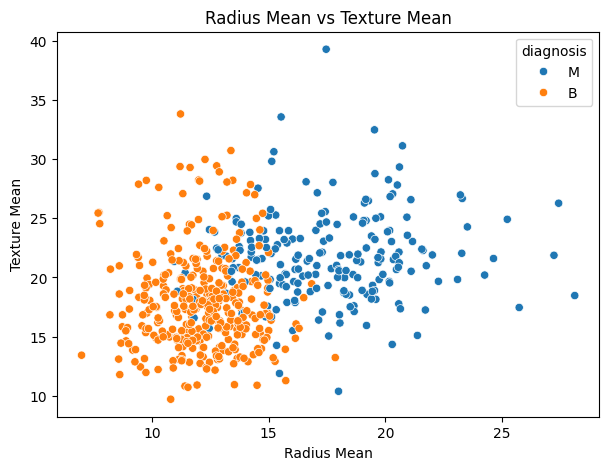

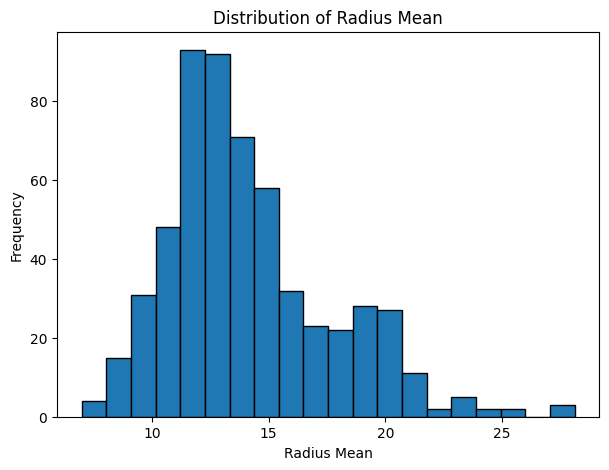

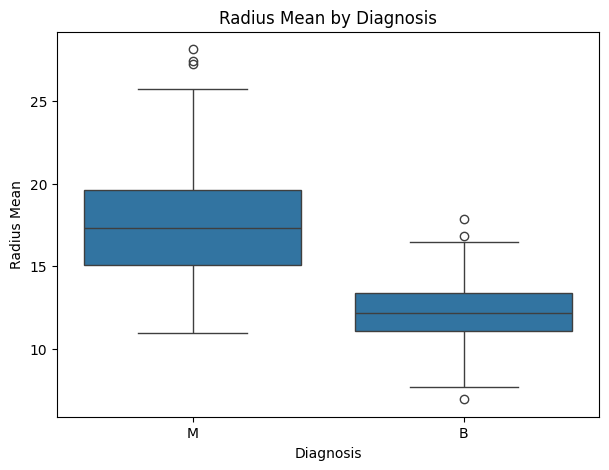

In [4]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="radius_mean",
    y="texture_mean",
    hue="diagnosis"
)
plt.title("Radius Mean vs Texture Mean")
plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(df["radius_mean"], bins=20, edgecolor="black")
plt.title("Distribution of Radius Mean")
plt.xlabel("Radius Mean")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="diagnosis",
    y="radius_mean"
)
plt.title("Radius Mean by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Radius Mean")
plt.show()


3. Apply Gaussian Naïve Bayes to predict diagnosis using the numerical features,
with an 80:20 train-test split.

In [5]:
# Remove unnecessary ID column if present
if "id" in df.columns:
    df = df.drop("id", axis=1)

# Convert diagnosis into numerical values
# M = Malignant, B = Benign
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})


# Select numerical features
X = df.select_dtypes(include=["int64", "float64"]).drop(
    "diagnosis", axis=1
)

# Target variable
y = df["diagnosis"]


# Split the data into training and testing sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Create Gaussian Naïve Bayes model
model = GaussianNB()


# Train the model
model.fit(X_train, y_train)


# Predict diagnosis
y_pred = model.predict(X_test)


4. Display the classification report and accuracy.

In [6]:
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Benign", "Malignant"]
))


# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")


Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.96      0.94        72
   Malignant       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114

Accuracy: 0.9210526315789473
Accuracy Percentage: 92.10526315789474 %
